## Filter velocity field

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import glob
from scipy import signal
import niskine 

import mplniw.utils as ut
import mplniw.plot as pl
import mplniw.sigp as sp
import gsw
import pandas as pd
import cmocean as cm

In [2]:
import phdequinox.utils as ut

In [2]:
from dask.distributed import Client, LocalCluster
#
cluster = LocalCluster()
#
#from dask_jobqueue import PBSCluster
#cluster = PBSCluster(cores=2, memory='24GB') #processes=7, cores=7
#w = cluster.scale(jobs=4)
#
client = Client(cluster)


To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
State start
  Scheduler at:     tcp://127.0.0.1:50892
  dashboard at:  http://127.0.0.1:8787/status
        Start Nanny at: 'tcp://127.0.0.1:50895'
        Start Nanny at: 'tcp://127.0.0.1:50896'
        Start Nanny at: 'tcp://127.0.0.1:50897'
        Start Nanny at: 'tcp://127.0.0.1:50898'
Register worker <WorkerState 'tcp://127.0.0.1:50904', name: 1, status: init, memory: 0, processing: 0>
Starting worker compute stream, tcp://127.0.0.1:50904
Starting established connection to tcp://127.0.0.1:50909
Register worker <WorkerState 'tcp://127.0.0.1:50903', name: 0, status: init, memory: 0, processing: 0>
Starting worker compute stream, tcp://127.0.0.1:50903
Starting established connection to tcp://127.0.0.1:50906
Register worker <WorkerState 'tcp://127.0.0.1:50910', name: 3, status: init, memory: 0, processing: 0>
Starting worker compute stream, tcp://127.0.0.1:50910


In [3]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 8.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:50892,Workers: 4
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 8.00 GiB
Comm: tcp://127.0.0.1:50903,Total threads: 2
Dashboard: http://127.0.0.1:50905/status,Memory: 2.00 GiB
Nanny: tcp://127.0.0.1:50895,


In [2]:
#Load moorings coordinates
conf = niskine.io.load_config()
m1lon, m1lat, m1bottom_depth = niskine.io.mooring_location(mooring=1)
m2lon, m2lat, m2bottom_depth = niskine.io.mooring_location(mooring=2)
m3lon, m3lat, m3bottom_depth = niskine.io.mooring_location(mooring=3)
#Directories
root_dir = '/Users/zcasparcohen/codes/NIW/data/'
figdir='/Users/zcasparcohen/codes/NIW/figures_vid/'

In [5]:
ds = xr.open_dataset(root_dir+'niskine_mooring.nc') # outputs
grid= xr.open_dataset(root_dir+'niskine_mooring_grid.nc') # CROCO grid

In [ ]:
#time
t0,t1 = '2001-01-06T16:00:00','2001-01-29T15:00:16'
t_storm = '2001-01-08'

time = pd.date_range(start=t0,periods=552,freq='1H')

In [17]:
#assign time coord
ds=ds.assign_coords({'time':time})

In [20]:
#ds['lat_u'] = grid.lat_u
#ds['lat_v'] = grid.lat_v
#ds['lon_u'] = grid.lon_u
#ds['lon_v'] = grid.lon_v
ds['lat_rho'] = grid.lat_rho
ds['lon_rho'] = grid.lon_rho
ds['x_rho'] = grid.x_rho
ds['y_rho'] = grid.y_rho
ds['eta_rho'] = grid.eta_rho
ds['xi_rho'] = grid.xi_rho
ds['eta_v'] = grid.eta_v
ds['xi_u'] = grid.xi_u

In [21]:
def u2rho(var_u):
    """ Change from velocity to rho grid (CROCO/ROMS)
    ----------------------------------------------------
    Parameters:
    var_u: array, variable in u grid 
    ----------------------------------------------------
    Returns:
    var_rho:array, interpolated variable on rho grid
    """
    K,N,M,L = var_u.shape
    if M>L:
        Lp=L+1;
        Lm=L-1;
        var_rho=np.zeros((K,N,M,Lp));
        var_rho[:,:,:, 1:L] = 0.5 * (var_u[:,:,:, 0:Lm] + var_u[:,:,:, 1:L])
        var_rho[:,:,:, 0] = var_rho[:,:,:, 1]
        var_rho[:,:,:, Lp-1] = var_rho[:,:,:, L-1]
    elif L>M:
        Mp=M+1;
        Mm=M-1;
        var_rho=var_rho=np.zeros((K,N,Mp,L));
        var_rho[:,:,1:M,:] = 0.5 * (var_u[:,:,0:Mm,:] + var_u[:,:,1:M,:])
        var_rho[:,:,0,:] = var_rho[:,:,1,:]
        var_rho[:,:,Mp-1,:] = var_rho[:,:,M-1,:]
    else:
        print('Check var_u shape')
    return var_rho

In [23]:
#interpolating u and v on rho grid
u_rho = xr.apply_ufunc(u2rho,ds.u, input_core_dims=[['time','depth','eta_rho','xi_u']],output_core_dims=[['time','depth','eta_rho','xi_rho']],dask="parallelized")
v_rho = xr.apply_ufunc(u2rho,ds.v, input_core_dims=[['time','depth','eta_v','xi_rho']],output_core_dims=[['time','depth','eta_rho','xi_rho']],dask="parallelized")

In [24]:
#Changing to latlon coordinates
u_latlon=u_rho*np.cos(grid.angle*np.pi/180)-v_rho*np.sin(grid.angle*np.pi/180)
v_latlon=v_rho*np.cos(grid.angle*np.pi/180)+u_rho*np.sin(grid.angle*np.pi/180)

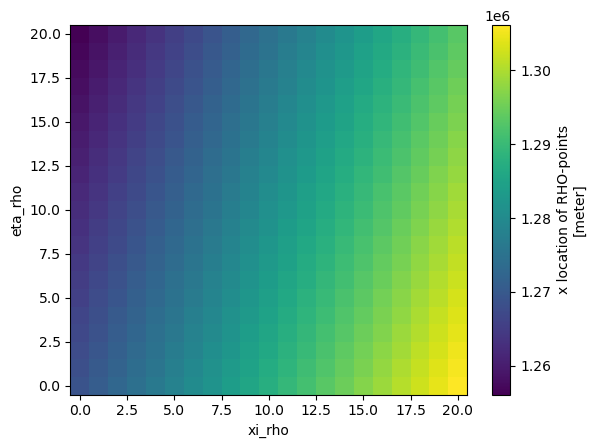

In [25]:
ds.x_rho.plot()

In [ ]:
u_latlon=u_latlon.assign_coords({'x':ds.x_rho.mean('eta_rho'),'y':ds.y_rho.mean('xi_rho')})
v_latlon=v_latlon.assign_coords({'x':ds.x_rho.mean('eta_rho'),'y':ds.y_rho.mean('xi_rho')})

u_latlon=u_latlon.rename({'eta_rho':'lat','xi_rho':'lon'})
v_latlon=v_latlon.rename({'eta_rho':'lat','xi_rho':'lon'})

u_latlon['lat'] = ds.lat_rho.mean('xi_rho').values
u_latlon['lon'] = ds.lon_rho.mean('eta_rho').values

v_latlon['lat'] = ds.lat_rho.mean('xi_rho').values
v_latlon['lon'] = ds.lon_rho.mean('eta_rho').values

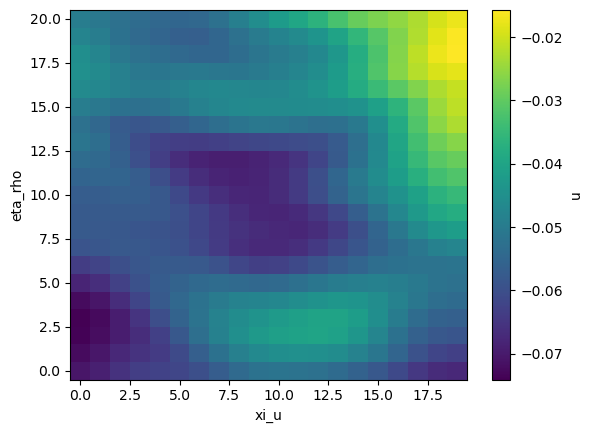

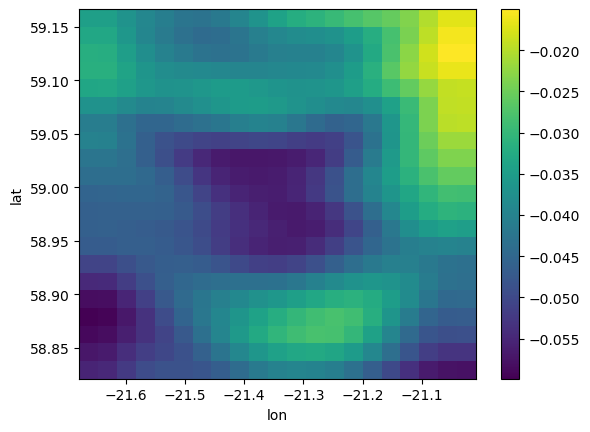

In [29]:
ds.u.mean(['time','depth']).plot()
plt.figure()
u_latlon.mean(['time','depth']).plot()

In [30]:
#kinetic energy
ke = 0.5*(u_latlon**2+v_latlon**2)

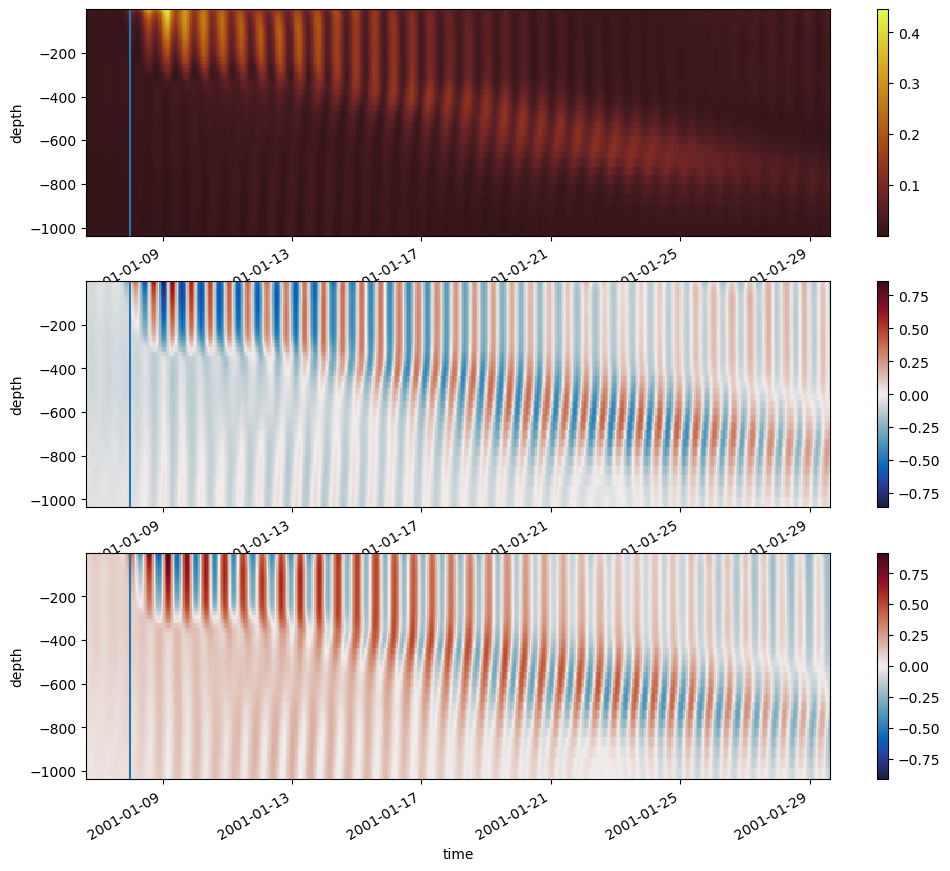

In [31]:
fig,ax=plt.subplots(3,1,figsize=(12,10))
ke.mean(['lat','lon']).plot(ax=ax[0],y='depth',cmap=cm.cm.solar)
u_latlon.mean(['lat','lon']).plot(ax=ax[1],y='depth',cmap=cm.cm.balance)
v_latlon.mean(['lat','lon']).plot(ax=ax[2],y='depth',cmap=cm.cm.balance)
for a in ax:
    a.axvline(np.datetime64(t_storm))

In [32]:
# Circle radius around moorings
R=gsw.distance([m1lon,m2lon],[m1lat,m2lat])/(2*np.sin(60*np.pi/180))
#Coordinates of the center of the mooring array 
latitudes = [m*np.pi/180 for m in [m1lat,m2lat,m3lat]]
longitudes = [m*np.pi/180 for m in [m1lon,m2lon,m3lon]]
sumx = np.sum(np.cos(latitudes)*np.cos(longitudes))/3
sumy = np.sum(np.cos(latitudes)*np.sin(longitudes))/3
sumz = np.sum(np.sin(latitudes))/3
midlon = 180*np.arctan2(sumy,sumx)/np.pi
hyp = np.sqrt(sumx*sumx+sumy*sumy)
midlat = 180*np.arctan2(sumz,hyp)/np.pi

In [33]:
import cartopy.crs as ccrs


In [36]:
#generating image for animation of kinetic energy
for i in range(u_rho.time.size):
    subplot_kws=dict(projection=ccrs.LambertConformal(central_longitude=-20.0,central_latitude=60.0),
                     facecolor='white')
    
    fig=plt.figure(figsize=[4,4])
    p = ke.isel(time=i,depth=0).plot.contourf(x='lon', y='lat',
                      vmin=0, vmax=5e-1,
                      cmap=cm.cm.solar,
                      subplot_kws=subplot_kws,
                      transform=ccrs.PlateCarree(),
                      levels=30,
                      add_labels=False,
                      add_colorbar=False)
    
    #p.axes.scatter([m1lon,m2lon,m3lon],[m1lat,m2lat,m3lat],c='k', transform=ccrs.PlateCarree())
    #p.axes.text(m1lon+0.05,m1lat, 'M1',size=20,transform=ccrs.PlateCarree());p.axes.text(m2lon+0.05,m2lat, 'M2',size=20,transform=ccrs.PlateCarree());
    #p.axes.text(m3lon-0.3,m3lat, 'M3',size=20,transform=ccrs.PlateCarree());
    #p.axes.scatter(midlon,midlat, transform=ccrs.PlateCarree());
    #plt.title(t.values)
    plt.savefig(figdir+'t_%s'%i)
    fig.clear();

/var/folders/vl/tj6snrv54zd212pkvk5g_l140000gn/T/ipykernel_36584/1300568677.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig=plt.figure(figsize=[4,4])


<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

...

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

<Figure size 400x400 with 0 Axes>

In [35]:
# Save dataset if needed
if True:
    ds_latlon = xr.Dataset({'u':u_latlon,'v':v_latlon}) 
                       #,'ke':ke})
    ds_latlon.to_netcdf(root_dir+'roms_latlon.nc')
if False:
    ds_latlon=xr.open_dataset(root_dir+'roms_latlon_500m.nc')

In [36]:
midlon,midlat=ds_latlon.lon.median(),ds_latlon.lat.median()

In [37]:
fc = ut.coriolis(midlat)*3600*24/2/np.pi #coriolis frequency

In [38]:
#Definition filter
dt = 1/(24)  # Time step in days unit
signal='lp'
Tw = 5  # Kernel length
if signal=='bp':
    omega = ut.coriolis(lat)*3600*24/(2*np.pi)  # Central frequency
    bandwidth = 0.2
    h = ut.generate_filter(omega,dt=dt,T=Tw,bandwidth=bandwidth,lat=lat,pass_zero=False)  # Best filter
elif signal=='lp':
    fc=ut.coriolis(midlat)*3600*24/(2*np.pi)  # Coriolis frequency
    #omega = 2.  #Cutoff frequency
    omega = 1/(fc.values-0.5)  #Cutoff frequency
    bandwidth = None 
    h = ut.generate_filter(omega,dt=dt,T=Tw,bandwidth=bandwidth,lat=midlat,pass_zero=True)  # Best filter
else:
    print('Filter not defined')
h_hat, w = ut.filter_response(h, dt=dt)  #Filter response

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


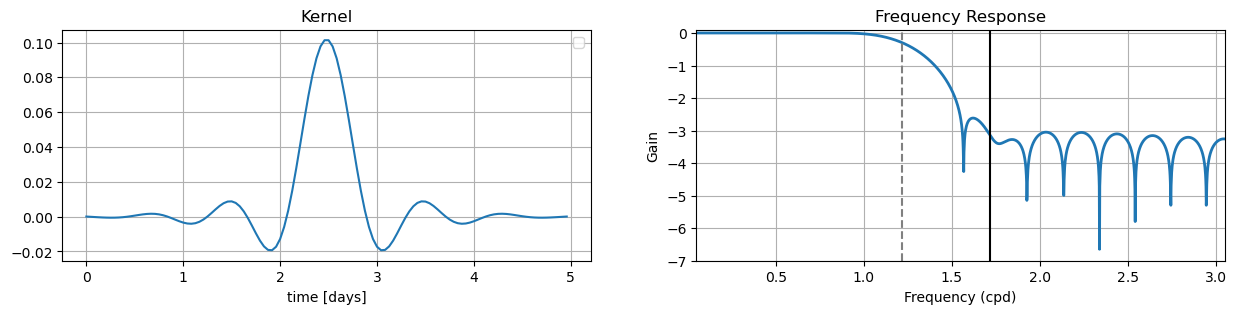

In [47]:
#Plot filter and response in the frequency domain
t = np.arange(0,Tw,dt)
fig, axes = plt.subplots(1,2, figsize=(15,3))
ax = axes[0]
ax.plot(t, h)
ax.grid()
ax.set_xlabel('time [days]')
ax.set_title('Kernel')
ax.legend()


ax = axes[1]

ax.plot(w, np.log10(abs(h_hat)), linewidth=2)
ax.axvline(fc, color='k')
#ax.axvline(omega-bandwidth, color='k',ls='--')
#ax.axvline(omega+bandwidth, color='k',ls='--')
#ax.axvline(1.96, color='grey', ls='--')
ax.axvline(1/omega, color='grey', ls='--')
ax.set_xlabel('Frequency (cpd)')
ax.set_ylabel('Gain')
ax.set_title('Frequency Response')
#ax.set_ylim(-0.05, 1.05)
ax.set_ylim(-7, 0.1)
ax.set_xlim(0.05, 3.05)
ax.grid(True)

In [41]:
ds_latlon = ds_latlon.transpose("depth","lat", "lon", "time") #transpose datatset for filter

In [42]:
#Definition of variables for energy transfers estimates
ds_latlon['usq'] = ds_latlon.u**2
ds_latlon['vsq'] = ds_latlon.v**2
ds_latlon['uv'] = ds_latlon.u*ds_latlon.v
col = ['u','v','vsq','usq','uv'] #

In [43]:
#Apply lowpass filter
ds_filt = sp.wrap_filter(ds_latlon,h,columns=col)

In [44]:
#Save filtered data
ds_filt.to_netcdf(root_dir+'roms_filtered.nc')

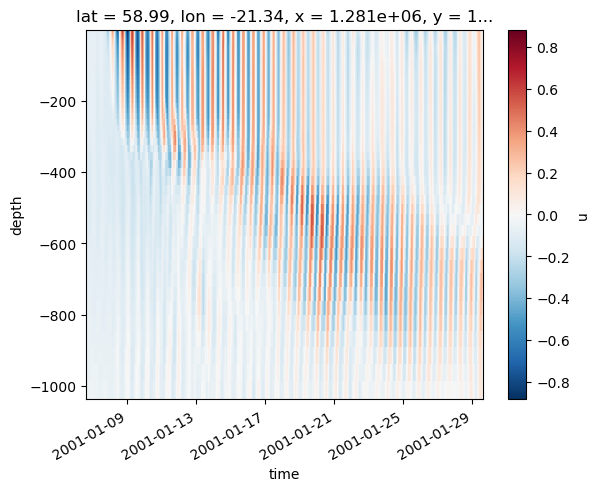

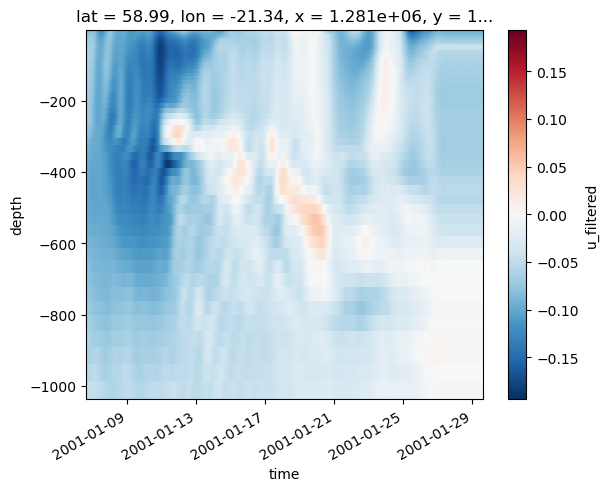

In [45]:
ds_filt.u.isel(lat=10,lon=10).plot()
plt.figure()
ds_filt.u_filtered.isel(lat=10,lon=10).plot()